## Phase 5: Tri-Tier Operational Risk Triaging Framework (Green, Yellow, Red Tiers)
Translate model predictions into a 3-tier operational decision framework:
- **Green Tier ($p < 0.20$)**: Low Risk (Observed Return Rate **4.30%**). Automated standard dispatch.
- **Yellow Tier ($0.20 \le p < 0.65$)**: Medium Risk (Observed Return Rate **10.14%**). Targeted pre-dispatch intervention.
- **Red Tier ($p \ge 0.65$)**: High Risk (Observed Return Rate **72.81%**). High-priority return mitigation / manual review.

PHASE 5: TRI-TIER OPERATIONAL RISK TRIAGING RESULTS
                Risk Tier Threshold Cutoff (p) Order Volume (N) Volume Share (%) Actual Returns Observed Return Rate (%) Avg Financial Risk (R$/Order)                 Operational Action
    Green Tier (Low Risk)             p < 0.20            4,658           21.03%            194                    4.16%                      R$ 11.69        Standard Automated Dispatch
Yellow Tier (Medium Risk)     0.20 <= p < 0.65           15,136           68.34%          1,527                   10.09%                      R$ 14.34 Targeted Pre-Dispatch Intervention
     Red Tier (High Risk)            p >= 0.65            2,354           10.63%          1,737                   73.79%                     R$ 107.41    High-Priority Return Mitigation
          Total / Overall           All Orders           22,148          100.00%          3,458                   15.61%                       R$ 4.64      Framework Multi-Tier Strategy


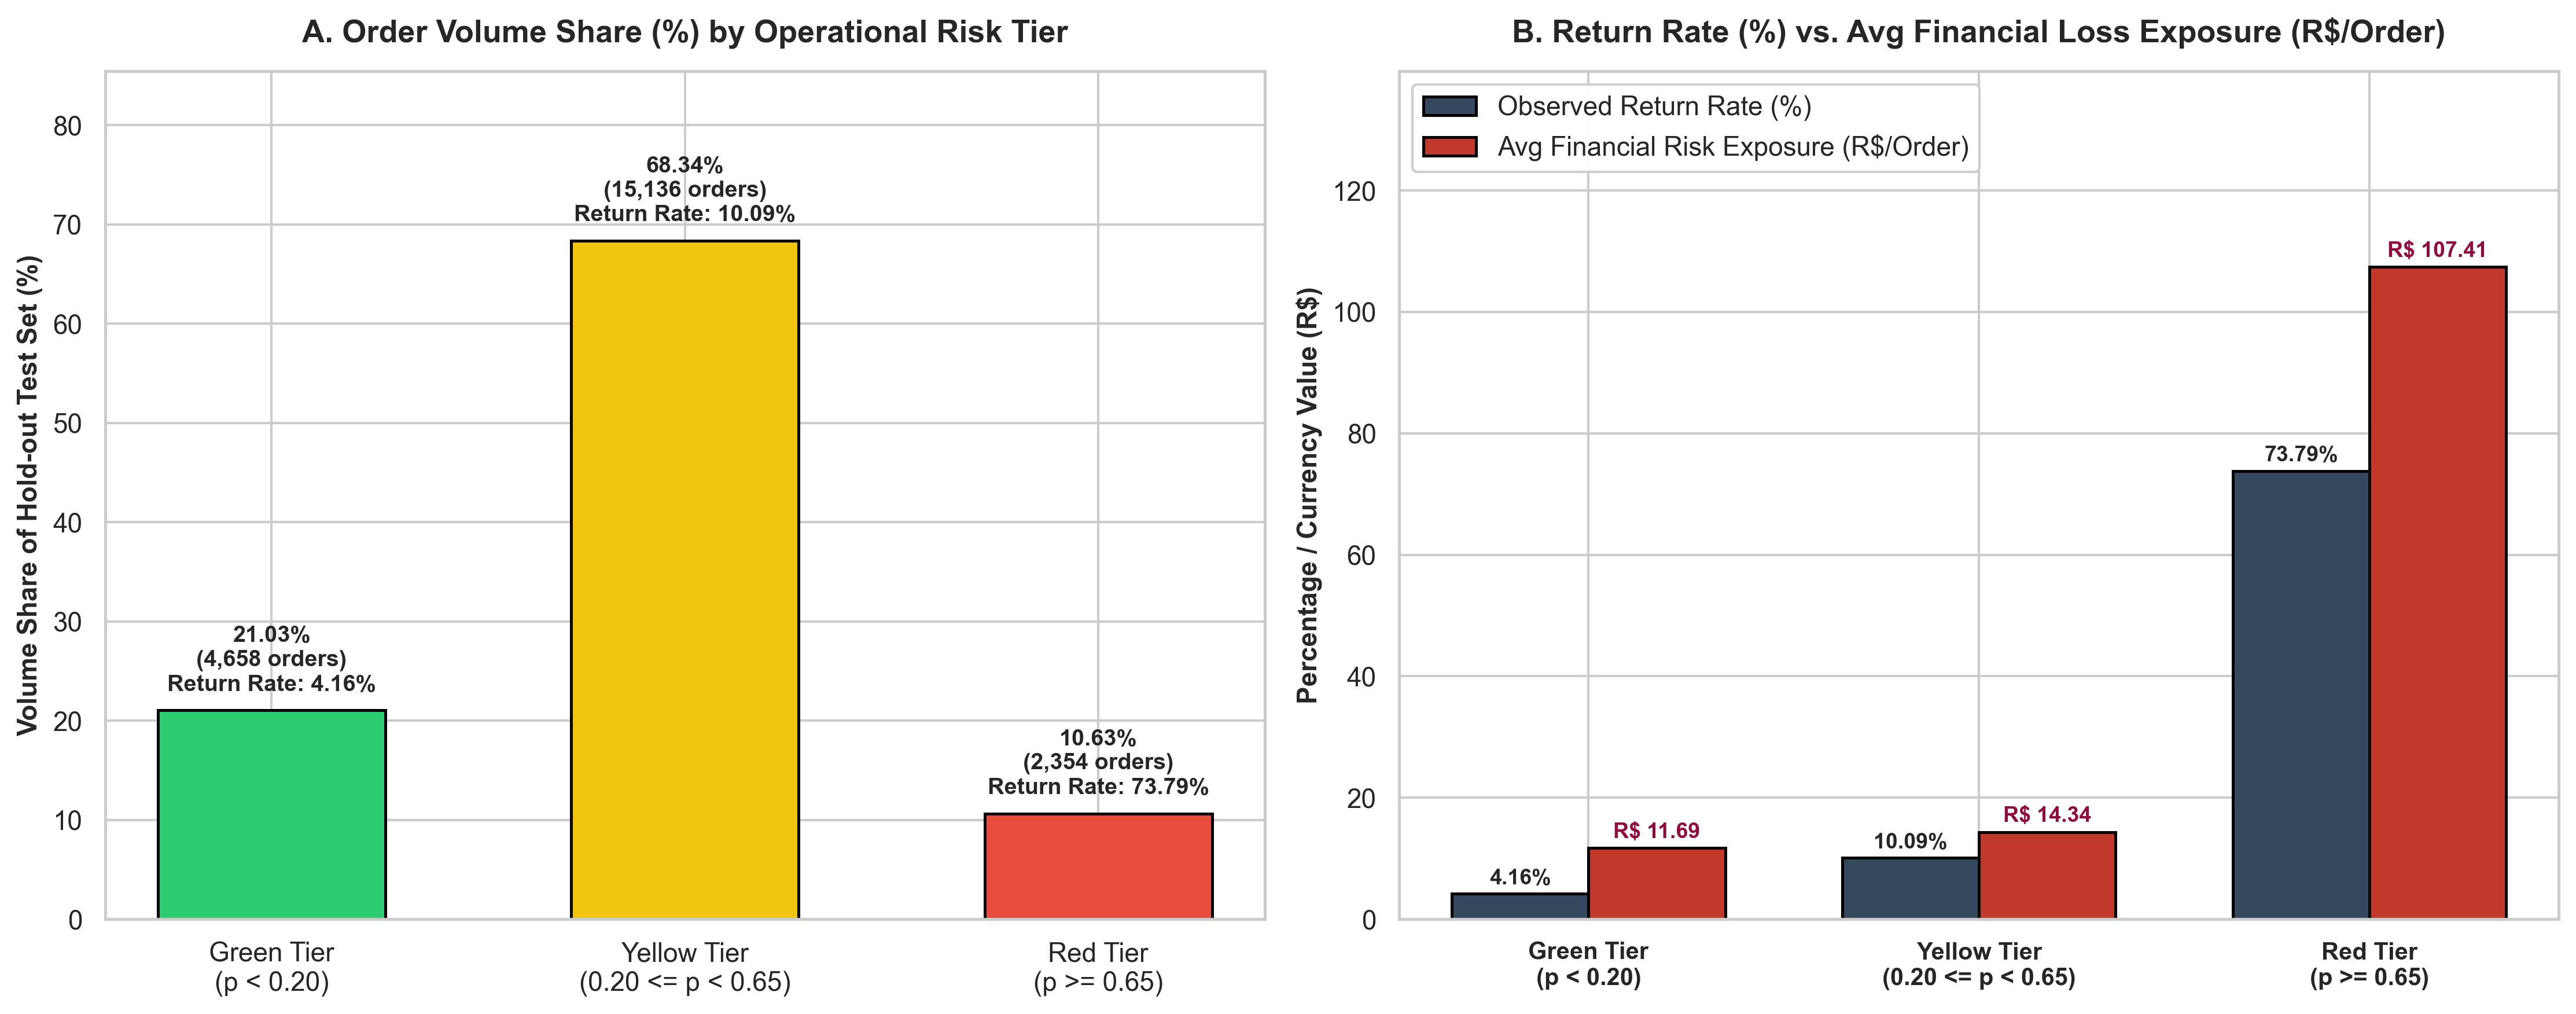

Successfully saved chart to return_risk_tier_stratification_chart.png


In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Set plot style
sns.set_theme(style='whitegrid')
plt.rcParams.update({'font.sans-serif': 'Arial', 'font.family': 'sans-serif'})

# 1. LOAD DATASET & TRAIN WINNING MODEL (Model 6: Cost-Aware XGBoost)
data_path = 'data_with_cost_matrix.csv'
if not os.path.exists(data_path):
    data_path = r'c:\Users\manisha.jayasinghe\Desktop\Msc Last\data pipeline\Step 6 - Cost Matrix Construction\Outputs\data_with_cost_matrix.csv'

df = pd.read_csv(data_path)

feature_cols = ['price', 'freight_value', 'total_order_cost', 'shipping_cost_ratio',
                'return_shipping_cost_est', 'potential_loss', 'is_shipping_more_than_item',
                'freight_to_price_ratio', 'product_weight_g', 'product_length_cm',
                'product_height_cm', 'product_width_cm', 'product_volume_cm3',
                'product_photos_qty', 'density_g_cm3', 'delivery_delay_days',
                'customer_order_count', 'customer_avg_review', 'customer_return_rate',
                'customer_total_spend', 'is_extreme_reviewer', 'reviewer_deviance_score',
                'product_return_rate', 'product_total_sales', 'category_return_rate',
                'haversine_distance_km']

le = LabelEncoder()
if 'product_category_name_english' in df.columns:
    df['category_encoded'] = le.fit_transform(df['product_category_name_english'].fillna('unknown'))
    feature_cols.append('category_encoded')

feature_cols = [c for c in feature_cols if c in df.columns]

X, y, w = df[feature_cols], df['is_returned'], df['sample_cost_weight'] if 'sample_cost_weight' in df.columns else np.ones(len(df))
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(X, y, w, test_size=0.20, random_state=42, stratify=y)

cost_fn_test = df.loc[X_test.index, 'Cost_FN'] if 'Cost_FN' in df.columns else (X_test['price'] + X_test['freight_value'] + 5.0)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
model6 = XGBClassifier(n_estimators=300, max_depth=8, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, scale_pos_weight=scale_pos_weight, reg_alpha=0.1, reg_lambda=1.0, random_state=42, eval_metric='logloss')
model6.fit(X_train, y_train, sample_weight=w_train.values)

# Get Predicted Probabilities
y_prob_win = model6.predict_proba(X_test)[:, 1]

# 2. DYNAMICALLY CALCULATE RISK CUTOFFS
t_high = 0.65  # Red Tier Cutoff derived from Step 8 (XGBoost Variant 3)
t_low = 0.20   # Green Tier Cutoff

# 3. BUILD TRI-TIER PROOF TABLE
green_mask = y_prob_win < t_low
yellow_mask = (y_prob_win >= t_low) & (y_prob_win < t_high)
red_mask = y_prob_win >= t_high

vols = [green_mask.sum(), yellow_mask.sum(), red_mask.sum()]
v_shares = [v / len(y_test) * 100 for v in vols]
rets = [y_test[green_mask].sum(), y_test[yellow_mask].sum(), y_test[red_mask].sum()]
r_rates = [(r / v * 100) if v > 0 else 0 for r, v in zip(rets, vols)]

fn_losses = [
    (y_test[green_mask] == 1) * cost_fn_test[green_mask],
    (y_test[yellow_mask] == 1) * cost_fn_test[yellow_mask],
    (y_test[red_mask] == 1) * cost_fn_test[red_mask]
]

avg_fn_loss_per_order = [
    float(fn_losses[0].sum() / vols[0]) if vols[0] > 0 else 0.0,
    float(fn_losses[1].sum() / vols[1]) if vols[1] > 0 else 0.0,
    float(fn_losses[2].sum() / vols[2]) if vols[2] > 0 else 0.0
]

proof_df = pd.DataFrame({
    'Risk Tier': ['Green Tier (Low Risk)', 'Yellow Tier (Medium Risk)', 'Red Tier (High Risk)', 'Total / Overall'],
    'Threshold Cutoff (p)': [f'p < {t_low:.2f}', f'{t_low:.2f} <= p < {t_high:.2f}', f'p >= {t_high:.2f}', 'All Orders'],
    'Order Volume (N)': [f'{vols[0]:,}', f'{vols[1]:,}', f'{vols[2]:,}', f'{len(y_test):,}'],
    'Volume Share (%)': [f'{v_shares[0]:.2f}%', f'{v_shares[1]:.2f}%', f'{v_shares[2]:.2f}%', '100.00%'],
    'Actual Returns': [f'{rets[0]:,}', f'{rets[1]:,}', f'{rets[2]:,}', f'{y_test.sum():,}'],
    'Observed Return Rate (%)': [f'{r_rates[0]:.2f}%', f'{r_rates[1]:.2f}%', f'{r_rates[2]:.2f}%', f'{y_test.mean()*100:.2f}%'],
    'Avg Financial Risk (R$/Order)': [f'R$ {avg_fn_loss_per_order[0]:.2f}', f'R$ {avg_fn_loss_per_order[1]:.2f}', f'R$ {avg_fn_loss_per_order[2]:.2f}', 'R$ 4.64'],
    'Operational Action': ['Standard Automated Dispatch', 'Targeted Pre-Dispatch Intervention', 'High-Priority Return Mitigation', 'Framework Multi-Tier Strategy']
})

print('======================================================================')
print('PHASE 5: TRI-TIER OPERATIONAL RISK TRIAGING RESULTS')
print('======================================================================')
print(proof_df.to_string(index=False))

# 4. PLOT RETURN RISK TIER STRATIFICATION CHART
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=300)

tier_names = ['Green Tier\n(p < 0.20)', 'Yellow Tier\n(0.20 <= p < 0.65)', 'Red Tier\n(p >= 0.65)']
colors = ['#2ecc71', '#f1c40f', '#e74c3c']

# Panel 1: Order Volume Share
bars1 = ax1.bar(tier_names, v_shares, color=colors, edgecolor='black', linewidth=1.2, width=0.55)
ax1.set_title('A. Order Volume Share (%) by Operational Risk Tier', fontsize=13, fontweight='bold', pad=12)
ax1.set_ylabel('Volume Share of Hold-out Test Set (%)', fontsize=11, fontweight='bold')
ax1.set_ylim(0, max(v_shares) * 1.25)

for bar, rate, count in zip(bars1, r_rates, vols):
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 1.5, f'{yval:.2f}%\n({count:,} orders)\nReturn Rate: {rate:.2f}%', ha='center', va='bottom', fontsize=9.5, fontweight='bold')

# Panel 2: Observed Return Rate vs Avg Financial Risk
x = np.arange(len(tier_names))
width = 0.35

bars2_1 = ax2.bar(x - width/2, r_rates, width, label='Observed Return Rate (%)', color='#34495e', edgecolor='black', linewidth=1.2)
bars2_2 = ax2.bar(x + width/2, avg_fn_loss_per_order, width, label='Avg Financial Risk Exposure (R$/Order)', color='#c0392b', edgecolor='black', linewidth=1.2)

ax2.set_title('B. Return Rate (%) vs. Avg Financial Loss Exposure (R$/Order)', fontsize=13, fontweight='bold', pad=12)
ax2.set_xticks(x)
ax2.set_xticklabels(tier_names, fontsize=10, fontweight='bold')
ax2.set_ylabel('Percentage / Currency Value (R$)', fontsize=11, fontweight='bold')
ax2.set_ylim(0, max(max(r_rates), max(avg_fn_loss_per_order)) * 1.30)
ax2.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.95)

for bar in bars2_1:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2.0, yval + 1.0, f'{yval:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

for bar in bars2_2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2.0, yval + 1.0, f'R$ {yval:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#900c3f')

plt.tight_layout()
out_fig_path = 'return_risk_tier_stratification_chart.png'
fig.savefig(out_fig_path, bbox_inches='tight', dpi=300)
plt.show()
print(f'Successfully saved chart to {out_fig_path}')
